<a href="https://colab.research.google.com/github/SiddharthaRathor/Hybrid-Recommendation-System-for-Personalized-Academic-Guidance/blob/main/Hybrid_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Hybrid Recommendation System for Personalized Academic Guidance

---

## Project Overview

This notebook implements a **Hybrid Recommendation System** for academic course guidance, combining:

| Component | Description |
|-----------|-------------|
| **Content-Based Filtering** | Recommends courses similar to what a user has already taken, using TF-IDF and Cosine Similarity |
| **Collaborative Filtering** | Leverages ratings from similar users using SVD (Singular Value Decomposition) |
| **Hybrid Layer** | Combines both signals with configurable weights |
| **Cold-Start Handling** | Handles new users and new courses gracefully |
| **Evaluation Metrics** | Precision@K, Recall@K, NDCG@K, MAP, Coverage, RMSE, MAE |

---

### Supported Datasets
- **MovieLens 100K** (auto-downloaded, mapped to course schema)
- **Coursera** datasets
- **Udemy** datasets
- **FutureLearn** datasets
- Any custom course dataset (via Dataset Adapter Layer)

---

> **Author:** Final-Year Research Project  
> **Platform:** Google Colab  
> **Python:** 3.x

---
## Section 1 — Install Dependencies

All required libraries are installed automatically. The `scikit-surprise` library provides SVD-based Collaborative Filtering.

In [1]:
!pip install -q "numpy<2"
!pip install -q scikit-surprise

In [2]:
# ============================================================
# SECTION 1: Install Dependencies
# ============================================================

import subprocess, sys

def install(package):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

packages = [
    'scikit-surprise',
    'pandas',
    'numpy',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'requests',
    'tqdm'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    install(pkg)

print('\n✅ All dependencies installed successfully.')

Installing scikit-surprise...
Installing pandas...
Installing numpy...
Installing scikit-learn...
Installing matplotlib...
Installing seaborn...
Installing requests...
Installing tqdm...

✅ All dependencies installed successfully.


---
## Section 2 — Import Libraries

In [3]:
# ============================================================
# SECTION 2: Import Libraries
# ============================================================

import os
import io
import zipfile
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict

# Scikit-Learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Surprise (Collaborative Filtering)
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import cross_validate, train_test_split as surprise_tts

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

# Output directory for saved plots and CSVs
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Libraries imported successfully.')
print(f'📁 Output directory: {OUTPUT_DIR}/')

✅ Libraries imported successfully.
📁 Output directory: outputs/


---
## Section 3 — Dataset Upload / Download

This section gives you **two options**:

1. **Auto-download MovieLens 100K** — the default for demonstration
2. **Upload your own dataset** — Coursera, Udemy, FutureLearn, or any CSV

Set `USE_MOVIELENS = True` (default) to skip uploading and download automatically.

In [4]:
# ============================================================
# SECTION 3: Dataset Upload / Download
# ============================================================

# ---- CONFIGURATION ----
# Set USE_MOVIELENS = True  -> auto-download MovieLens 100K
# Set USE_MOVIELENS = False -> upload your own dataset files
USE_MOVIELENS = True

# Raw data will be stored here before transformation
RAW_DATA = {}

# -------------------------------------------------------
# Option A: Auto-download MovieLens 100K
# -------------------------------------------------------
def download_movielens():
    """Download and parse MovieLens 100K dataset from GroupLens."""
    url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
    print('⬇️  Downloading MovieLens 100K...')
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    buf = io.BytesIO()
    with tqdm(total=total, unit='B', unit_scale=True, desc='MovieLens 100K') as bar:
        for chunk in response.iter_content(chunk_size=8192):
            buf.write(chunk)
            bar.update(len(chunk))
    buf.seek(0)

    with zipfile.ZipFile(buf) as z:
        # Ratings: u.data
        with z.open('ml-100k/u.data') as f:
            ratings_raw = pd.read_csv(
                f, sep='\t',
                names=['user_id', 'movie_id', 'rating', 'timestamp']
            )
        # Items: u.item (movies)
        genre_cols = [
            'unknown','Action','Adventure','Animation',"Children's",'Comedy',
            'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
            'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western'
        ]
        item_cols = ['movie_id','movie_title','release_date','video_release_date',
                     'IMDb_URL'] + genre_cols
        with z.open('ml-100k/u.item') as f:
            items_raw = pd.read_csv(
                f, sep='|', names=item_cols,
                encoding='latin-1', usecols=['movie_id','movie_title'] + genre_cols
            )

    print(f'✅ MovieLens loaded: {len(ratings_raw):,} ratings, {len(items_raw):,} movies')
    return ratings_raw, items_raw

# -------------------------------------------------------
# Option B: Upload your own CSV files
# -------------------------------------------------------
def upload_dataset():
    """Upload dataset files from local machine (Colab file upload)."""
    try:
        from google.colab import files
        print('📤 Please upload your dataset files (ratings CSV and courses/items CSV).')
        uploaded = files.upload()
        dataframes = {}
        for fname, content in uploaded.items():
            df = pd.read_csv(io.BytesIO(content))
            dataframes[fname] = df
            print(f'   Loaded: {fname} — {df.shape[0]} rows × {df.shape[1]} columns')
            print(f'   Columns: {list(df.columns)}')
        return dataframes
    except ImportError:
        print('⚠️  Not running in Colab. Please place your CSV files in the current directory.')
        return {}

# -------------------------------------------------------
# Execute based on configuration
# -------------------------------------------------------
if USE_MOVIELENS:
    movielens_ratings, movielens_items = download_movielens()
    RAW_DATA['source'] = 'movielens'
    RAW_DATA['ratings'] = movielens_ratings
    RAW_DATA['items']   = movielens_items
else:
    uploaded_data = upload_dataset()
    RAW_DATA['source'] = 'custom'
    RAW_DATA['uploaded'] = uploaded_data
    print('\n➡️  Proceed to Section 4 (Dataset Adapter Layer) to map your columns.')

print('\n✅ Dataset loading complete.')

⬇️  Downloading MovieLens 100K...


MovieLens 100K: 100%|██████████| 4.92M/4.92M [00:00<00:00, 9.51MB/s]


✅ MovieLens loaded: 100,000 ratings, 1,682 movies

✅ Dataset loading complete.


---
## Section 4 — Dataset Adapter Layer

The **Dataset Adapter Layer** is the core innovation that makes this notebook dataset-agnostic.

It auto-detects the dataset structure and maps any input schema to the **unified schema**:

```
ratings.csv  → user_id, course_id, rating
courses.csv  → course_id, course_title, course_category
```

Supported auto-detection:
- MovieLens 100K
- Coursera CSV exports
- Udemy CSV exports
- FutureLearn CSV exports
- Generic course datasets

In [5]:
# ============================================================
# SECTION 4: Dataset Adapter Layer
# ============================================================

class DatasetAdapter:
    """
    Detects dataset structure and converts any supported format
    into the unified schema:
        ratings  : user_id, course_id, rating
        courses  : course_id, course_title, course_category
    """

    # ----- Known column mappings per dataset type -----
    SCHEMA_MAP = {
        'movielens': {
            'ratings': {
                'user_id':   'user_id',
                'course_id': 'movie_id',
                'rating':    'rating'
            },
            'courses': {
                'course_id':       'movie_id',
                'course_title':    'movie_title',
                'course_category': None  # derived from genre columns
            }
        },
        'coursera': {
            'ratings': {
                'user_id':   ['user_id', 'student_id', 'learner_id'],
                'course_id': ['course_id', 'course_url', 'id'],
                'rating':    ['rating', 'stars', 'score', 'course_rating']
            },
            'courses': {
                'course_id':       ['course_id', 'id', 'course_url'],
                'course_title':    ['course_name', 'title', 'name', 'course_title'],
                'course_category': ['category', 'subject', 'topic', 'domain', 'course_category']
            }
        },
        'udemy': {
            'ratings': {
                'user_id':   ['user_id', 'subscriber_id'],
                'course_id': ['course_id', 'id'],
                'rating':    ['avg_rating', 'rating', 'num_reviews']
            },
            'courses': {
                'course_id':       ['id', 'course_id'],
                'course_title':    ['course_title', 'title'],
                'course_category': ['subject', 'category', 'topic']
            }
        },
        'futurelearn': {
            'ratings': {
                'user_id':   ['learner_id', 'user_id'],
                'course_id': ['course_run_id', 'course_id'],
                'rating':    ['overall_rate', 'rating', 'score']
            },
            'courses': {
                'course_id':       ['course_run_id', 'course_id'],
                'course_title':    ['course_title', 'title', 'name'],
                'course_category': ['category', 'subject', 'topic']
            }
        }
    }

    MOVIELENS_GENRES = [
        'unknown','Action','Adventure','Animation',"Children's",'Comedy',
        'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
        'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western'
    ]

    def __init__(self):
        self.detected_type = None

    def _find_col(self, df, candidates):
        """Return first matching column name from candidates list."""
        if isinstance(candidates, str):
            return candidates if candidates in df.columns else None
        for c in candidates:
            if c in df.columns:
                return c
        return None

    def detect_type(self, df_ratings=None, df_items=None):
        """Auto-detect dataset type from column names."""
        if df_ratings is not None and 'movie_id' in (df_ratings.columns.tolist() +
                                                      (df_items.columns.tolist() if df_items is not None else [])):
            self.detected_type = 'movielens'
        elif df_ratings is not None:
            cols = set(df_ratings.columns.str.lower())
            if 'learner_id' in cols or 'course_run_id' in cols:
                self.detected_type = 'futurelearn'
            elif 'subscriber_id' in cols or 'avg_rating' in cols:
                self.detected_type = 'udemy'
            elif 'student_id' in cols or 'course_url' in cols:
                self.detected_type = 'coursera'
            else:
                self.detected_type = 'generic'
        else:
            self.detected_type = 'generic'
        print(f'🔍 Detected dataset type: {self.detected_type.upper()}')
        return self.detected_type

    def _adapt_movielens(self, df_ratings, df_items):
        """Convert MovieLens 100K to unified course schema."""
        # Build genre string for each movie
        available_genres = [g for g in self.MOVIELENS_GENRES if g in df_items.columns]
        def get_genres(row):
            return '|'.join([g for g in available_genres if row[g] == 1]) or 'Unknown'
        df_items['course_category'] = df_items.apply(get_genres, axis=1)

        courses = df_items[['movie_id', 'movie_title', 'course_category']].copy()
        courses.columns = ['course_id', 'course_title', 'course_category']

        ratings = df_ratings[['user_id', 'movie_id', 'rating']].copy()
        ratings.columns = ['user_id', 'course_id', 'rating']

        return ratings, courses

    def _adapt_generic(self, df_ratings, df_items=None):
        """Best-effort mapping for unknown dataset types."""
        rating_candidates = {
            'user_id':   ['user_id','userId','learner_id','student_id','subscriber_id','uid'],
            'course_id': ['course_id','courseId','item_id','movie_id','id','course_url'],
            'rating':    ['rating','rate','score','stars','avg_rating','overall_rate']
        }
        r = {}
        for field, cands in rating_candidates.items():
            col = self._find_col(df_ratings, cands)
            if col is None:
                # If still not found, use positional fallback
                col = df_ratings.columns[list(rating_candidates.keys()).index(field)]
                print(f'⚠️  Could not auto-detect "{field}" column — using "{col}" as fallback.')
            r[field] = col

        ratings = df_ratings[[r['user_id'], r['course_id'], r['rating']]].copy()
        ratings.columns = ['user_id', 'course_id', 'rating']

        if df_items is not None:
            item_cands = {
                'course_id':       ['course_id','id','movie_id','item_id'],
                'course_title':    ['course_title','title','name','movie_title','course_name'],
                'course_category': ['category','subject','genre','topic','course_category']
            }
            ic = {}
            for field, cands in item_cands.items():
                col = self._find_col(df_items, cands)
                if col is None and len(df_items.columns) > list(item_cands.keys()).index(field):
                    col = df_items.columns[list(item_cands.keys()).index(field)]
                ic[field] = col

            keep = [ic[f] for f in ['course_id','course_title','course_category'] if ic[f] is not None]
            courses = df_items[keep].copy()
            courses.columns = [f for f in ['course_id','course_title','course_category'] if ic[f] is not None]
        else:
            # Build courses from ratings alone
            courses = ratings[['course_id']].drop_duplicates().copy()
            courses['course_title'] = 'Course_' + courses['course_id'].astype(str)
            courses['course_category'] = 'Unknown'

        return ratings, courses

    def adapt(self, df_ratings, df_items=None):
        """Main entry point — detect type and convert to unified schema."""
        dtype = self.detect_type(df_ratings, df_items)

        if dtype == 'movielens':
            return self._adapt_movielens(df_ratings, df_items)
        else:
            return self._adapt_generic(df_ratings, df_items)


# -------------------------------------------------------
# Main load_dataset() function
# -------------------------------------------------------
def load_dataset(raw_data: dict) -> tuple:
    """
    Load and adapt dataset from RAW_DATA dict.
    Returns: (ratings_df, courses_df) in unified schema.
    """
    adapter = DatasetAdapter()

    if raw_data['source'] == 'movielens':
        ratings, courses = adapter.adapt(
            raw_data['ratings'],
            raw_data['items']
        )
    elif raw_data['source'] == 'custom':
        uploaded = raw_data['uploaded']
        dfs = list(uploaded.values())
        if len(dfs) == 1:
            ratings, courses = adapter.adapt(dfs[0])
        elif len(dfs) == 2:
            ratings, courses = adapter.adapt(dfs[0], dfs[1])
        else:
            print('⚠️  More than 2 files uploaded. Using first two.')
            ratings, courses = adapter.adapt(dfs[0], dfs[1])
    else:
        raise ValueError('Unknown data source in RAW_DATA.')

    return ratings, courses


print('✅ Dataset Adapter Layer defined successfully.')

✅ Dataset Adapter Layer defined successfully.


---
## Section 5 — Dataset Transformation

Apply the adapter to transform raw data into the unified schema, then save `ratings.csv` and `courses.csv`.

In [6]:
# ============================================================
# SECTION 5: Dataset Transformation
# ============================================================

# Run the adapter
ratings_df, courses_df = load_dataset(RAW_DATA)

# ---- Basic Cleaning ----
# Enforce correct types
ratings_df['user_id']   = ratings_df['user_id'].astype(int)
ratings_df['course_id'] = ratings_df['course_id'].astype(int)
ratings_df['rating']    = pd.to_numeric(ratings_df['rating'], errors='coerce')
ratings_df.dropna(subset=['rating'], inplace=True)

courses_df['course_id'] = courses_df['course_id'].astype(int)
courses_df['course_title']    = courses_df['course_title'].fillna('Unknown Title').astype(str)
courses_df['course_category'] = courses_df['course_category'].fillna('Unknown').astype(str)

# Remove duplicate ratings (keep last)
ratings_df.drop_duplicates(subset=['user_id', 'course_id'], keep='last', inplace=True)
ratings_df.reset_index(drop=True, inplace=True)

# Save to CSV
ratings_df.to_csv(os.path.join(OUTPUT_DIR, 'ratings.csv'), index=False)
courses_df.to_csv(os.path.join(OUTPUT_DIR, 'courses.csv'), index=False)

# ---- Summary ----
print('=== Unified Schema: ratings_df ===')
print(ratings_df.head())
print(f'\nShape: {ratings_df.shape}')
print(f'Rating range: [{ratings_df["rating"].min()}, {ratings_df["rating"].max()}]')

print('\n=== Unified Schema: courses_df ===')
print(courses_df.head())
print(f'\nShape: {courses_df.shape}')

print('\n✅ Transformation complete. ratings.csv and courses.csv saved.')

🔍 Detected dataset type: MOVIELENS
=== Unified Schema: ratings_df ===
   user_id  course_id  rating
0      196        242       3
1      186        302       3
2       22        377       1
3      244         51       2
4      166        346       1

Shape: (100000, 3)
Rating range: [1, 5]

=== Unified Schema: courses_df ===
   course_id       course_title              course_category
0          1   Toy Story (1995)  Animation|Children's|Comedy
1          2   GoldenEye (1995)    Action|Adventure|Thriller
2          3  Four Rooms (1995)                     Thriller
3          4  Get Shorty (1995)          Action|Comedy|Drama
4          5     Copycat (1995)         Crime|Drama|Thriller

Shape: (1682, 3)

✅ Transformation complete. ratings.csv and courses.csv saved.


---
## Section 6 — Exploratory Data Analysis (EDA)

Understanding the data before modelling is critical. We explore:
- Rating distributions
- User activity
- Course popularity
- Category distribution
- Sparsity of the user-course matrix

  DATASET STATISTICS
  Total Users   : 943
  Total Courses : 1,682
  Total Ratings : 100,000
  Sparsity      : 93.6953%
  Avg Rating    : 3.530
  Median Rating : 4.0


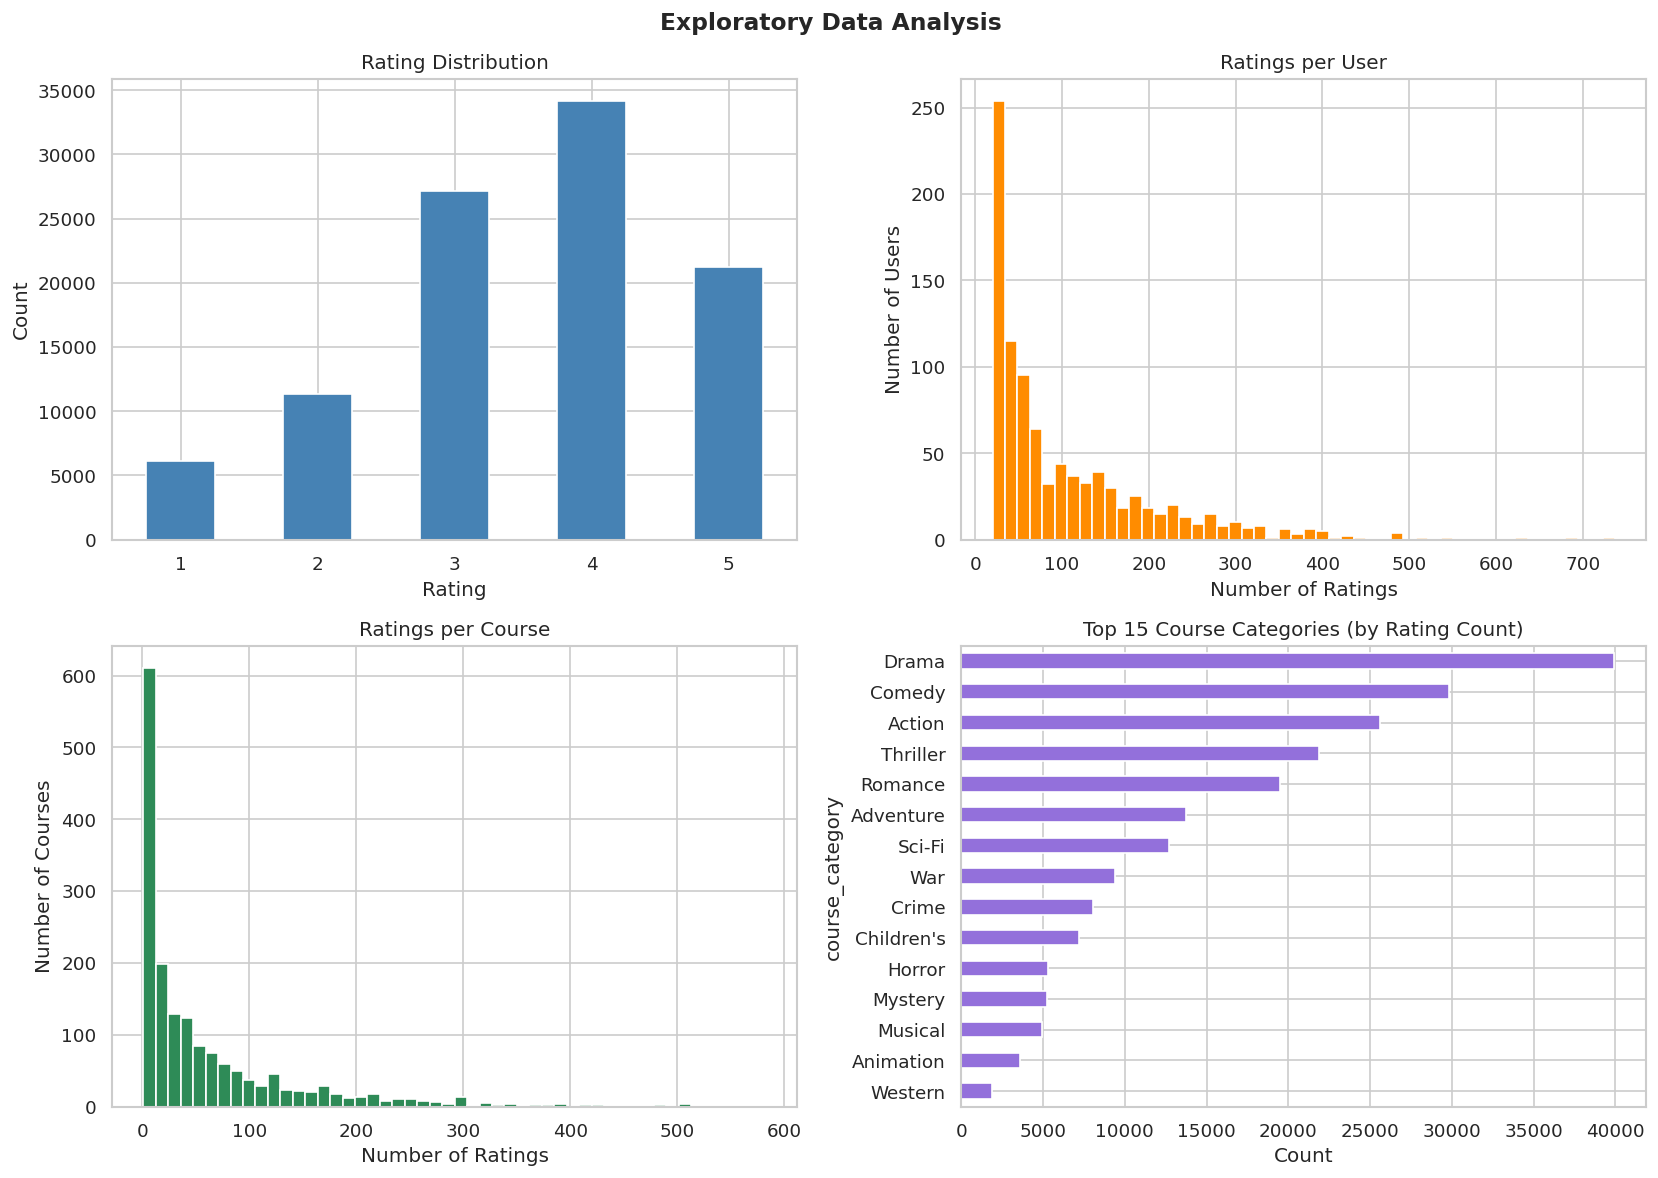

✅ EDA plots saved.


In [7]:
# ============================================================
# SECTION 6: Exploratory Data Analysis
# ============================================================

n_users   = ratings_df['user_id'].nunique()
n_courses = ratings_df['course_id'].nunique()
n_ratings = len(ratings_df)
sparsity  = 1 - n_ratings / (n_users * n_courses)

print('=' * 45)
print('  DATASET STATISTICS')
print('=' * 45)
print(f'  Total Users   : {n_users:,}')
print(f'  Total Courses : {n_courses:,}')
print(f'  Total Ratings : {n_ratings:,}')
print(f'  Sparsity      : {sparsity:.4%}')
print(f'  Avg Rating    : {ratings_df["rating"].mean():.3f}')
print(f'  Median Rating : {ratings_df["rating"].median():.1f}')
print('=' * 45)

# ---- Plot 1: Rating Distribution ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Rating histogram
ax = axes[0, 0]
ratings_df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# Ratings per user
ax = axes[0, 1]
ratings_per_user = ratings_df.groupby('user_id')['rating'].count()
ax.hist(ratings_per_user, bins=50, color='darkorange', edgecolor='white')
ax.set_title('Ratings per User')
ax.set_xlabel('Number of Ratings')
ax.set_ylabel('Number of Users')

# Ratings per course
ax = axes[1, 0]
ratings_per_course = ratings_df.groupby('course_id')['rating'].count()
ax.hist(ratings_per_course, bins=50, color='seagreen', edgecolor='white')
ax.set_title('Ratings per Course')
ax.set_xlabel('Number of Ratings')
ax.set_ylabel('Number of Courses')

# Category distribution (top 15)
ax = axes[1, 1]
merged = ratings_df.merge(courses_df[['course_id','course_category']], on='course_id', how='left')
# Expand multi-label categories (e.g. MovieLens genres are pipe-separated)
cat_series = merged['course_category'].str.split('|').explode()
cat_counts = cat_series.value_counts().head(15)
cat_counts.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Top 15 Course Categories (by Rating Count)')
ax.set_xlabel('Count')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_overview.png'), bbox_inches='tight')
plt.show()
print('✅ EDA plots saved.')

---
## Section 7 — Data Preprocessing

Prepare data for both Content-Based and Collaborative Filtering:
- Filter cold users/items (min interactions threshold)
- Build course metadata for TF-IDF
- Construct lookup mappings

In [8]:
# ============================================================
# SECTION 7: Data Preprocessing
# ============================================================

# ---- 7.1  Minimum interaction filtering ----
MIN_USER_RATINGS   = 5   # users with fewer ratings are excluded from CF training
MIN_COURSE_RATINGS = 3   # courses with fewer ratings are excluded

user_counts   = ratings_df['user_id'].value_counts()
course_counts = ratings_df['course_id'].value_counts()

active_users   = user_counts[user_counts   >= MIN_USER_RATINGS].index
active_courses = course_counts[course_counts >= MIN_COURSE_RATINGS].index

filtered_ratings = ratings_df[
    ratings_df['user_id'].isin(active_users) &
    ratings_df['course_id'].isin(active_courses)
].copy().reset_index(drop=True)

print(f'After filtering (min {MIN_USER_RATINGS} ratings/user, {MIN_COURSE_RATINGS}/course):')
print(f'  Users   : {filtered_ratings["user_id"].nunique():,}')
print(f'  Courses : {filtered_ratings["course_id"].nunique():,}')
print(f'  Ratings : {len(filtered_ratings):,}')

# ---- 7.2  Course metadata for TF-IDF ----
# Combine title + category into a single text feature
courses_df['metadata'] = (
    courses_df['course_title'].str.lower().str.replace(r'[^\w\s]', ' ', regex=True) +
    ' ' +
    courses_df['course_category'].str.lower().str.replace('[|]', ' ', regex=True)
)

# ---- 7.3  Build lookup dictionaries ----
course_id_to_title    = dict(zip(courses_df['course_id'], courses_df['course_title']))
course_id_to_category = dict(zip(courses_df['course_id'], courses_df['course_category']))
title_to_course_id    = {v: k for k, v in course_id_to_title.items()}

# Index mapping for matrix operations
course_ids  = courses_df['course_id'].tolist()
course_idx  = {cid: idx for idx, cid in enumerate(course_ids)}

print('\n✅ Preprocessing complete.')
print(f'   Course metadata sample: {courses_df["metadata"].iloc[0]}')

After filtering (min 5 ratings/user, 3/course):
  Users   : 943
  Courses : 1,473
  Ratings : 99,723

✅ Preprocessing complete.
   Course metadata sample: toy story  1995  animation children's comedy


---
## Section 8 — Content-Based Filtering

**Content-Based Filtering** recommends courses based on their features (title and category), without needing other users' data.

### Algorithm
1. Build a **TF-IDF matrix** from course metadata (title + category)
2. Compute **Cosine Similarity** between all course pairs
3. Given a user's rated courses, aggregate similarity scores to rank unseen courses

**Cosine Similarity formula:**
$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

In [9]:
# ============================================================
# SECTION 8: Content-Based Filtering
# ============================================================

class ContentBasedFilter:
    """
    TF-IDF + Cosine Similarity content-based recommender.
    Operates on course metadata (title + category).
    """

    def __init__(self, courses_df: pd.DataFrame):
        self.courses_df = courses_df.reset_index(drop=True).copy()
        self.course_ids = self.courses_df['course_id'].tolist()
        self.idx_map    = {cid: i for i, cid in enumerate(self.course_ids)}
        self.tfidf_matrix = None
        self.cosine_sim   = None

    def fit(self):
        """Compute TF-IDF and cosine similarity matrix."""
        tfidf = TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            min_df=1,
            stop_words='english'
        )
        self.tfidf_matrix = tfidf.fit_transform(self.courses_df['metadata'])
        self.cosine_sim   = cosine_similarity(self.tfidf_matrix, self.tfidf_matrix)
        print(f'✅ TF-IDF matrix: {self.tfidf_matrix.shape}')
        print(f'✅ Cosine similarity matrix: {self.cosine_sim.shape}')
        return self

    def recommend_similar_courses(self, course_id: int, n: int = 10) -> pd.DataFrame:
        """
        Return top-N courses most similar to the given course_id.
        Useful for item-to-item recommendations and cold-start (new course).
        """
        if course_id not in self.idx_map:
            print(f'⚠️  course_id {course_id} not found in course catalog.')
            return pd.DataFrame()

        idx = self.idx_map[course_id]
        sim_scores = list(enumerate(self.cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        # Skip the course itself (index 0 in sorted)
        sim_scores = [(i, s) for i, s in sim_scores if i != idx][:n]

        results = []
        for i, score in sim_scores:
            cid = self.course_ids[i]
            results.append({
                'course_id':       cid,
                'course_title':    course_id_to_title.get(cid, 'Unknown'),
                'course_category': course_id_to_category.get(cid, 'Unknown'),
                'similarity_score': round(score, 4)
            })

        return pd.DataFrame(results)

    def recommend_content_based(self, user_id: int, ratings_df: pd.DataFrame,
                                 n: int = 10) -> pd.DataFrame:
        """
        Recommend top-N unseen courses for a user based on their rating history.
        Aggregates similarity scores weighted by user's own ratings.
        """
        user_ratings = ratings_df[ratings_df['user_id'] == user_id]
        if user_ratings.empty:
            print(f'⚠️  No ratings found for user {user_id}.')
            return pd.DataFrame()

        # Weighted similarity: sum(rating * sim_vector) for each rated course
        scored = np.zeros(len(self.course_ids))
        rated_ids = set()

        for _, row in user_ratings.iterrows():
            cid    = row['course_id']
            rating = row['rating']
            if cid in self.idx_map:
                rated_ids.add(cid)
                idx = self.idx_map[cid]
                scored += rating * self.cosine_sim[idx]

        # Zero out already-rated courses
        for cid in rated_ids:
            if cid in self.idx_map:
                scored[self.idx_map[cid]] = 0

        # Normalize
        if scored.max() > 0:
            scored = scored / scored.max()

        top_indices = np.argsort(scored)[::-1][:n]
        results = []
        for i in top_indices:
            if scored[i] > 0:
                cid = self.course_ids[i]
                results.append({
                    'course_id':       cid,
                    'course_title':    course_id_to_title.get(cid, 'Unknown'),
                    'course_category': course_id_to_category.get(cid, 'Unknown'),
                    'content_score':   round(scored[i], 4)
                })

        return pd.DataFrame(results)

    def get_score(self, user_id: int, course_id: int, ratings_df: pd.DataFrame) -> float:
        """
        Return a single content-based score for (user, course) pair.
        Used by the hybrid layer.
        """
        user_ratings = ratings_df[ratings_df['user_id'] == user_id]
        if user_ratings.empty or course_id not in self.idx_map:
            return 0.0

        target_idx = self.idx_map[course_id]
        total_score = 0.0
        total_weight = 0.0

        for _, row in user_ratings.iterrows():
            cid = row['course_id']
            if cid in self.idx_map and cid != course_id:
                sim = self.cosine_sim[self.idx_map[cid], target_idx]
                total_score  += row['rating'] * sim
                total_weight += row['rating']

        return total_score / total_weight if total_weight > 0 else 0.0


# ---- Instantiate and fit ----
cb_model = ContentBasedFilter(courses_df)
cb_model.fit()

# Quick test
sample_course = courses_df['course_id'].iloc[0]
print(f'\n🎓 Sample: Courses similar to "{course_id_to_title[sample_course]}"')
print(cb_model.recommend_similar_courses(sample_course, n=5).to_string(index=False))

✅ TF-IDF matrix: (1682, 5997)
✅ Cosine similarity matrix: (1682, 1682)

🎓 Sample: Courses similar to "Toy Story (1995)"
 course_id                      course_title                      course_category  similarity_score
      1066                      Balto (1995)                 Animation|Children's            0.3777
      1219             Goofy Movie, A (1995)  Animation|Children's|Comedy|Romance            0.3736
      1470           Gumby: The Movie (1995)                 Animation|Children's            0.3215
       542                 Pocahontas (1995) Animation|Children's|Musical|Romance            0.3174
      1072 Pyromaniac's Love Story, A (1995)                       Comedy|Romance            0.3010


---
## Section 9 — Collaborative Filtering (SVD)

**Collaborative Filtering** recommends courses based on patterns in the collective rating matrix, learning latent factors that represent user preferences and course characteristics.

### SVD (Singular Value Decomposition)
SVD factorizes the rating matrix $R$ into:
$$R \approx U \Sigma V^T$$
where $U$ = user factors, $\Sigma$ = diagonal singular values, $V^T$ = item factors.

The Surprise library implements **FunkSVD** (biased matrix factorization), optimized via stochastic gradient descent.

In [15]:
# ============================================================
# SECTION 9: Collaborative Filtering (SVD)
# ============================================================

class CollaborativeFilter:
    """
    SVD-based collaborative filtering using the Surprise library.
    """

    def __init__(self, n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02):
        self.n_factors = n_factors
        self.n_epochs  = n_epochs
        self.lr_all    = lr_all
        self.reg_all   = reg_all
        self.algo      = None
        self.trainset  = None
        self.testset   = None
        self.rating_min = None
        self.rating_max = None

    def train_collaborative_model(self, ratings_df: pd.DataFrame,
                                   test_size: float = 0.2,
                                   random_state: int = 42):
        """
        Train SVD model and evaluate on held-out test set.
        Returns RMSE and MAE.
        """
        self.rating_min = ratings_df['rating'].min()
        self.rating_max = ratings_df['rating'].max()

        reader = Reader(rating_scale=(self.rating_min, self.rating_max))
        data   = Dataset.load_from_df(
            ratings_df[['user_id', 'course_id', 'rating']], reader
        )

        self.trainset, self.testset = surprise_tts(
        data,
        test_size=test_size,
        random_state=random_state
        )

# Also keep a full trainset reference for prediction
        self.full_trainset = data.build_full_trainset()

        self.algo = SVD(
            n_factors=self.n_factors,
            n_epochs=self.n_epochs,
            lr_all=self.lr_all,
            reg_all=self.reg_all,
            random_state=random_state,
            verbose=False
        )

        print(f'🔧 Training SVD (factors={self.n_factors}, epochs={self.n_epochs})...')
        self.algo.fit(self.trainset)

        predictions = self.algo.test(self.testset)
        rmse = accuracy.rmse(predictions, verbose=False)
        mae  = accuracy.mae(predictions,  verbose=False)

        print(f'✅ Training complete.')
        print(f'   RMSE: {rmse:.4f}')
        print(f'   MAE : {mae:.4f}')

        return rmse, mae, predictions

    def predict_rating(self, user_id: int, course_id: int) -> float:
        """
        Predict rating for a (user, course) pair.
        Returns clipped predicted rating.
        """
        if self.algo is None:
            raise RuntimeError('Model not trained. Call train_collaborative_model() first.')
        pred = self.algo.predict(str(user_id), str(course_id))
        # Clip to valid rating range
        return float(np.clip(pred.est, self.rating_min, self.rating_max))

    def recommend_cf(self, user_id: int, all_course_ids: list,
                     rated_ids: set, n: int = 10) -> pd.DataFrame:
        """
        Recommend top-N unseen courses for user using SVD predictions.
        """
        candidates = [cid for cid in all_course_ids if cid not in rated_ids]
        preds = []
        for cid in candidates:
            score = self.predict_rating(user_id, cid)
            preds.append((cid, score))
        preds.sort(key=lambda x: x[1], reverse=True)
        top_n = preds[:n]
        return pd.DataFrame([
            {
                'course_id':    cid,
                'course_title': course_id_to_title.get(cid, 'Unknown'),
                'cf_score':     round(sc, 4)
            }
            for cid, sc in top_n
        ])


# ---- Instantiate, train and evaluate ----
cf_model = CollaborativeFilter(n_factors=100, n_epochs=20)
cf_rmse, cf_mae, cf_predictions = cf_model.train_collaborative_model(filtered_ratings)

print(f'\n📊 Collaborative Filtering Results:')
print(f'   RMSE = {cf_rmse:.4f}')
print(f'   MAE  = {cf_mae:.4f}')

🔧 Training SVD (factors=100, epochs=20)...
✅ Training complete.
   RMSE: 0.9346
   MAE : 0.7353

📊 Collaborative Filtering Results:
   RMSE = 0.9346
   MAE  = 0.7353


---
## Section 10 — Hybrid Recommendation System

The **Hybrid Layer** combines Content-Based and Collaborative scores using a weighted formula:

$$\text{HybridScore}(u, c) = \alpha \cdot \text{CF\_score}(u, c) + \beta \cdot \text{CB\_score}(u, c)$$

**Default weights:** $\alpha = 0.7$ (CF), $\beta = 0.3$ (Content-Based)

Both scores are normalized to $[0, 1]$ before combining, ensuring fair weighting.

In [16]:
# ============================================================
# SECTION 10: Hybrid Recommendation System
# ============================================================

class HybridRecommender:
    """
    Combines Content-Based Filtering and Collaborative Filtering
    using configurable alpha/beta weights.

    hybrid_score = alpha * cf_score + beta * content_score
    """

    def __init__(self, cf_model: CollaborativeFilter,
                       cb_model: ContentBasedFilter,
                       alpha: float = 0.7,
                       beta:  float = 0.3):
        assert abs(alpha + beta - 1.0) < 1e-6, 'alpha + beta must equal 1.0'
        self.cf    = cf_model
        self.cb    = cb_model
        self.alpha = alpha
        self.beta  = beta

    def set_weights(self, alpha: float, beta: float):
        """Dynamically update CF/CB weights."""
        assert abs(alpha + beta - 1.0) < 1e-6, 'alpha + beta must equal 1.0'
        self.alpha = alpha
        self.beta  = beta
        print(f'✅ Weights updated → CF: {alpha}, CB: {beta}')

    def _normalize(self, scores: dict) -> dict:
        """Min-max normalize a score dict to [0, 1]."""
        if not scores:
            return scores
        mn = min(scores.values())
        mx = max(scores.values())
        if mx == mn:
            return {k: 0.5 for k in scores}
        return {k: (v - mn) / (mx - mn) for k, v in scores.items()}

    def recommend(self, user_id: int, ratings_df: pd.DataFrame,
                  n: int = 10) -> pd.DataFrame:
        """
        Generate top-N hybrid recommendations for a user.

        Parameters:
            user_id    : target user
            ratings_df : full ratings dataframe
            n          : number of recommendations

        Returns:
            DataFrame with course_id, title, cf_score, cb_score, hybrid_score
        """
        user_rated = set(
            ratings_df[ratings_df['user_id'] == user_id]['course_id'].tolist()
        )
        all_course_ids = courses_df['course_id'].tolist()
        candidates = [c for c in all_course_ids if c not in user_rated]

        # Collect raw CF scores
        cf_raw = {}
        for cid in candidates:
            try:
                cf_raw[cid] = self.cf.predict_rating(user_id, cid)
            except Exception:
                cf_raw[cid] = 0.0

        # Collect raw CB scores
        cb_raw = {}
        for cid in candidates:
            cb_raw[cid] = self.cb.get_score(user_id, cid, ratings_df)

        # Normalize
        cf_norm = self._normalize(cf_raw)
        cb_norm = self._normalize(cb_raw)

        # Combine
        hybrid_scores = {
            cid: self.alpha * cf_norm.get(cid, 0.0) + self.beta * cb_norm.get(cid, 0.0)
            for cid in candidates
        }

        # Sort and return top-N
        top_n = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:n]

        results = []
        for cid, h_score in top_n:
            results.append({
                'course_id':       cid,
                'course_title':    course_id_to_title.get(cid, 'Unknown'),
                'course_category': course_id_to_category.get(cid, 'Unknown'),
                'cf_score':        round(cf_norm.get(cid, 0.0), 4),
                'cb_score':        round(cb_norm.get(cid, 0.0), 4),
                'hybrid_score':    round(h_score, 4)
            })

        return pd.DataFrame(results)


# ---- Instantiate hybrid recommender ----
hybrid = HybridRecommender(cf_model, cb_model, alpha=0.7, beta=0.3)

# Quick test
sample_user = filtered_ratings['user_id'].iloc[0]
print(f'🧪 Testing hybrid recommendations for user {sample_user}...')
sample_hybrid = hybrid.recommend(sample_user, filtered_ratings, n=5)
print(sample_hybrid.to_string(index=False))
print('\n✅ Hybrid Recommender ready.')

🧪 Testing hybrid recommendations for user 196...
 course_id                course_title course_category  cf_score  cb_score  hybrid_score
      1048        She's the One (1996)  Comedy|Romance       0.5    1.0000        0.6500
      1102             Two Much (1996)  Comedy|Romance       0.5    1.0000        0.6500
        49                 I.Q. (1994)  Comedy|Romance       0.5    0.7049        0.5615
       785             Only You (1994)  Comedy|Romance       0.5    0.7049        0.5615
      1457 Love Is All There Is (1996)    Comedy|Drama       0.5    0.6380        0.5414

✅ Hybrid Recommender ready.


---
## Section 11 — Cold-Start Handling

**Cold-start** is a fundamental challenge in recommendation systems:

- **New User**: No rating history → cannot run CF. Solution: recommend most popular / highest rated courses.
- **New Course**: No user interactions → cannot appear in CF. Solution: use TF-IDF metadata similarity.

Both strategies ensure the system always returns useful recommendations.

In [17]:
# ============================================================
# SECTION 11: Cold-Start Handling
# ============================================================

def recommend_for_new_user(ratings_df: pd.DataFrame,
                            courses_df: pd.DataFrame,
                            strategy: str = 'popularity',
                            n: int = 10) -> pd.DataFrame:
    """
    Cold-start recommendations for a brand-new user with no history.

    Parameters:
        strategy : 'popularity' → most rated courses
                   'rating'     → highest average rated courses
                   'combined'   → weighted blend of both
        n        : number of recommendations

    Returns:
        DataFrame of top-N recommended courses
    """
    MIN_VOTES = 10  # minimum number of ratings to be considered

    stats = ratings_df.groupby('course_id').agg(
        num_ratings=('rating', 'count'),
        avg_rating=('rating',  'mean')
    ).reset_index()

    stats = stats[stats['num_ratings'] >= MIN_VOTES].copy()

    # Normalize both metrics to [0, 1]
    scaler = MinMaxScaler()
    stats[['pop_score', 'avg_score']] = scaler.fit_transform(
        stats[['num_ratings', 'avg_rating']]
    )

    if strategy == 'popularity':
        stats['cold_score'] = stats['pop_score']
    elif strategy == 'rating':
        stats['cold_score'] = stats['avg_score']
    else:  # combined
        stats['cold_score'] = 0.5 * stats['pop_score'] + 0.5 * stats['avg_score']

    top_n = stats.nlargest(n, 'cold_score')

    result = top_n.merge(courses_df[['course_id','course_title','course_category']],
                          on='course_id', how='left')

    return result[['course_id','course_title','course_category',
                   'num_ratings','avg_rating','cold_score']].reset_index(drop=True)


def recommend_similar_new_course(new_course_title: str,
                                  new_course_category: str,
                                  cb_model: ContentBasedFilter,
                                  n: int = 10) -> pd.DataFrame:
    """
    Cold-start recommendations for a brand-new course.
    Uses TF-IDF similarity against the existing course catalog.

    Parameters:
        new_course_title    : title of the new course
        new_course_category : category/subject of the new course
        cb_model            : fitted ContentBasedFilter instance
        n                   : number of similar courses to return

    Returns:
        DataFrame of most similar existing courses
    """
    from sklearn.feature_extraction.text import TfidfVectorizer

    # Build a fresh TF-IDF that includes the new course
    new_metadata = (
        new_course_title.lower().replace(r'[^\w\s]', ' ') +
        ' ' +
        new_course_category.lower().replace('|', ' ')
    )

    all_metadata = cb_model.courses_df['metadata'].tolist() + [new_metadata]

    tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                             min_df=1, stop_words='english')
    tfidf_matrix = tfidf.fit_transform(all_metadata)

    # The new course is the last row
    new_vec = tfidf_matrix[-1]
    existing_vecs = tfidf_matrix[:-1]

    sims = cosine_similarity(new_vec, existing_vecs).flatten()
    top_idx = np.argsort(sims)[::-1][:n]

    results = []
    for i in top_idx:
        cid = cb_model.course_ids[i]
        results.append({
            'course_id':       cid,
            'course_title':    course_id_to_title.get(cid, 'Unknown'),
            'course_category': course_id_to_category.get(cid, 'Unknown'),
            'similarity_score': round(float(sims[i]), 4)
        })

    return pd.DataFrame(results)


# ---- Test Cold-Start ----
print('=== Cold-Start: New User (Popularity Strategy) ===')
new_user_recs = recommend_for_new_user(filtered_ratings, courses_df,
                                        strategy='combined', n=5)
print(new_user_recs[['course_title','num_ratings','avg_rating','cold_score']].to_string(index=False))

print('\n=== Cold-Start: New Course (TF-IDF Similarity) ===')
new_course_recs = recommend_similar_new_course(
    new_course_title='Introduction to Machine Learning',
    new_course_category='Computer Science | Data Science',
    cb_model=cb_model,
    n=5
)
print(new_course_recs.to_string(index=False))

print('\n✅ Cold-Start handlers ready.')

=== Cold-Start: New User (Popularity Strategy) ===
                  course_title  num_ratings  avg_rating  cold_score
              Star Wars (1977)          583    4.358491    0.979123
                  Fargo (1996)          508    4.155512    0.881716
     Return of the Jedi (1983)          507    4.007890    0.857597
                Contact (1997)          509    3.803536    0.827164
Raiders of the Lost Ark (1981)          420    4.252381    0.820180

=== Cold-Start: New Course (TF-IDF Similarity) ===
 course_id                                   course_title  course_category  similarity_score
       109 Mystery Science Theater 3000: The Movie (1996)    Comedy|Sci-Fi            0.1450
      1371                            Machine, The (1994)    Comedy|Horror            0.1317
      1220                         Higher Learning (1995)            Drama            0.1138
      1682      Scream of Stone (Schrei aus Stein) (1991)            Drama            0.0000
       554              

---
## Section 12 — Evaluation Metrics

We implement seven standard evaluation metrics for recommendation systems:

| Metric | Type | Description |
|--------|------|-------------|
| **RMSE** | Error | Root Mean Squared Error of predicted vs actual ratings |
| **MAE** | Error | Mean Absolute Error |
| **Precision@K** | Ranking | Fraction of top-K recommendations that are relevant |
| **Recall@K** | Ranking | Fraction of relevant items appearing in top-K |
| **NDCG@K** | Ranking | Normalized Discounted Cumulative Gain (position-aware) |
| **MAP** | Ranking | Mean Average Precision across all users |
| **Coverage** | Diversity | Fraction of the item catalog recommended to at least one user |

In [18]:
# ============================================================
# SECTION 12: Evaluation Metrics
# ============================================================

# ---- 12.1  Error Metrics (from Surprise predictions) ----

def compute_rmse(predictions) -> float:
    """
    Root Mean Squared Error.
    RMSE = sqrt( (1/N) * sum( (r_hat - r)^2 ) )
    Lower is better.
    """
    errors = [(p.r_ui - p.est) ** 2 for p in predictions]
    return float(np.sqrt(np.mean(errors)))

def compute_mae(predictions) -> float:
    """
    Mean Absolute Error.
    MAE = (1/N) * sum( |r_hat - r| )
    Lower is better.
    """
    errors = [abs(p.r_ui - p.est) for p in predictions]
    return float(np.mean(errors))


# ---- 12.2  Ranking Metrics ----

def get_top_n_surprise(predictions, n: int = 10, threshold: float = None) -> dict:
    """
    Build a dict of top-N predictions per user from Surprise predictions.
    threshold: minimum true rating to be considered 'relevant'.
    """
    top_n = defaultdict(list)
    for pred in predictions:
        top_n[pred.uid].append((pred.iid, pred.est, pred.r_ui))
    for uid in top_n:
        top_n[uid].sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = top_n[uid][:n]
    return top_n


def precision_at_k(predictions, k: int = 10, threshold: float = None) -> float:
    """
    Precision@K = |relevant ∩ recommended@K| / K

    Parameters:
        threshold : rating value above which an item is 'relevant'.
                    Defaults to the median rating.
    """
    if threshold is None:
        threshold = float(np.median([p.r_ui for p in predictions]))

    top_n = get_top_n_surprise(predictions, n=k)
    precisions = []
    for uid, user_preds in top_n.items():
        n_rel = sum(1 for _, _, r in user_preds if r >= threshold)
        precisions.append(n_rel / k if k > 0 else 0)
    return float(np.mean(precisions)) if precisions else 0.0


def recall_at_k(predictions, k: int = 10, threshold: float = None) -> float:
    """
    Recall@K = |relevant ∩ recommended@K| / |relevant|

    Parameters:
        threshold : rating value above which an item is 'relevant'.
    """
    if threshold is None:
        threshold = float(np.median([p.r_ui for p in predictions]))

    # All relevant items per user in the test set
    user_relevant = defaultdict(set)
    for pred in predictions:
        if pred.r_ui >= threshold:
            user_relevant[pred.uid].add(pred.iid)

    top_n = get_top_n_surprise(predictions, n=k)
    recalls = []
    for uid, user_preds in top_n.items():
        relevant = user_relevant[uid]
        if not relevant:
            continue
        recommended_ids = {iid for iid, _, _ in user_preds}
        recalls.append(len(relevant & recommended_ids) / len(relevant))
    return float(np.mean(recalls)) if recalls else 0.0


def ndcg_at_k(predictions, k: int = 10, threshold: float = None) -> float:
    """
    Normalized Discounted Cumulative Gain @ K.

    DCG@K  = sum_i [ rel_i / log2(i+2) ]
    IDCG@K = ideal DCG (all relevant items at top)
    NDCG@K = DCG@K / IDCG@K

    Uses graded relevance: actual_rating as relevance score.
    """
    top_n = get_top_n_surprise(predictions, n=k)
    ndcg_scores = []

    for uid, user_preds in top_n.items():
        # DCG
        dcg = sum(
            r_ui / np.log2(i + 2)
            for i, (_, _, r_ui) in enumerate(user_preds)
        )
        # IDCG: sort by true relevance
        ideal = sorted([r_ui for _, _, r_ui in user_preds], reverse=True)
        idcg  = sum(r / np.log2(i + 2) for i, r in enumerate(ideal))
        if idcg > 0:
            ndcg_scores.append(dcg / idcg)

    return float(np.mean(ndcg_scores)) if ndcg_scores else 0.0


def mean_average_precision(predictions, threshold: float = None) -> float:
    """
    Mean Average Precision (MAP).

    AP = (1/|R|) * sum_k [ P@k * rel(k) ]
    MAP = mean(AP) over all users

    Parameters:
        threshold : minimum rating to be considered relevant.
    """
    if threshold is None:
        threshold = float(np.median([p.r_ui for p in predictions]))

    user_preds_all = defaultdict(list)
    for pred in predictions:
        user_preds_all[pred.uid].append((pred.iid, pred.est, pred.r_ui))

    ap_scores = []
    for uid, upreds in user_preds_all.items():
        upreds_sorted = sorted(upreds, key=lambda x: x[1], reverse=True)
        n_rel    = sum(1 for _, _, r in upreds_sorted if r >= threshold)
        if n_rel == 0:
            continue
        hits, ap_sum = 0, 0.0
        for i, (_, _, r_ui) in enumerate(upreds_sorted, start=1):
            if r_ui >= threshold:
                hits += 1
                ap_sum += hits / i
        ap_scores.append(ap_sum / n_rel)

    return float(np.mean(ap_scores)) if ap_scores else 0.0


def catalog_coverage(predictions, all_course_ids: list, k: int = 10) -> float:
    """
    Catalog Coverage = |unique recommended items| / |all items|

    Measures how much of the catalog the system recommends.
    Higher is better (reduces filter bubble).
    """
    top_n = get_top_n_surprise(predictions, n=k)
    recommended = set()
    for uid, upreds in top_n.items():
        for iid, _, _ in upreds:
            recommended.add(iid)
    return len(recommended) / len(all_course_ids) if all_course_ids else 0.0


# ---- Run all evaluations ----
K_VALUES = [5, 10, 15, 20]
all_course_ids_str = [str(c) for c in courses_df['course_id'].tolist()]
rating_threshold = float(filtered_ratings['rating'].median())

eval_results = {}

eval_results['RMSE'] = compute_rmse(cf_predictions)
eval_results['MAE']  = compute_mae(cf_predictions)
eval_results['MAP']  = mean_average_precision(cf_predictions, threshold=rating_threshold)
eval_results['Coverage@10'] = catalog_coverage(cf_predictions, all_course_ids_str, k=10)

prec_k, rec_k, ndcg_k = {}, {}, {}
for k in K_VALUES:
    prec_k[k]  = precision_at_k(cf_predictions, k=k, threshold=rating_threshold)
    rec_k[k]   = recall_at_k(cf_predictions,    k=k, threshold=rating_threshold)
    ndcg_k[k]  = ndcg_at_k(cf_predictions,      k=k)

eval_results['Precision@K'] = prec_k
eval_results['Recall@K']    = rec_k
eval_results['NDCG@K']      = ndcg_k

print('=== Evaluation Results ===')
print(f'RMSE       : {eval_results["RMSE"]:.4f}')
print(f'MAE        : {eval_results["MAE"]:.4f}')
print(f'MAP        : {eval_results["MAP"]:.4f}')
print(f'Coverage@10: {eval_results["Coverage@10"]:.4f} ({eval_results["Coverage@10"]*100:.1f}%)')
print(f'\n{"K":>4}  {"Precision":>10}  {"Recall":>10}  {"NDCG":>10}')
print('-' * 40)
for k in K_VALUES:
    print(f'{k:>4}  {prec_k[k]:>10.4f}  {rec_k[k]:>10.4f}  {ndcg_k[k]:>10.4f}')

print('\n✅ Evaluation complete.')

=== Evaluation Results ===
RMSE       : 0.9346
MAE        : 0.7353
MAP        : 0.8062
Coverage@10: 0.4863 (48.6%)

   K   Precision      Recall        NDCG
----------------------------------------
   5      0.6925      0.5301      0.9629
  10      0.5739      0.7316      0.9581
  15      0.4846      0.8239      0.9571
  20      0.4212      0.8812      0.9570

✅ Evaluation complete.


---
## Section 13 — Recommendation Visualization

Visualizing evaluation metrics helps understand system behaviour across different K values. We generate six plots:
1. Precision@K
2. Recall@K
3. NDCG@K
4. Rating Distribution
5. Category Distribution
6. Recommendation Coverage

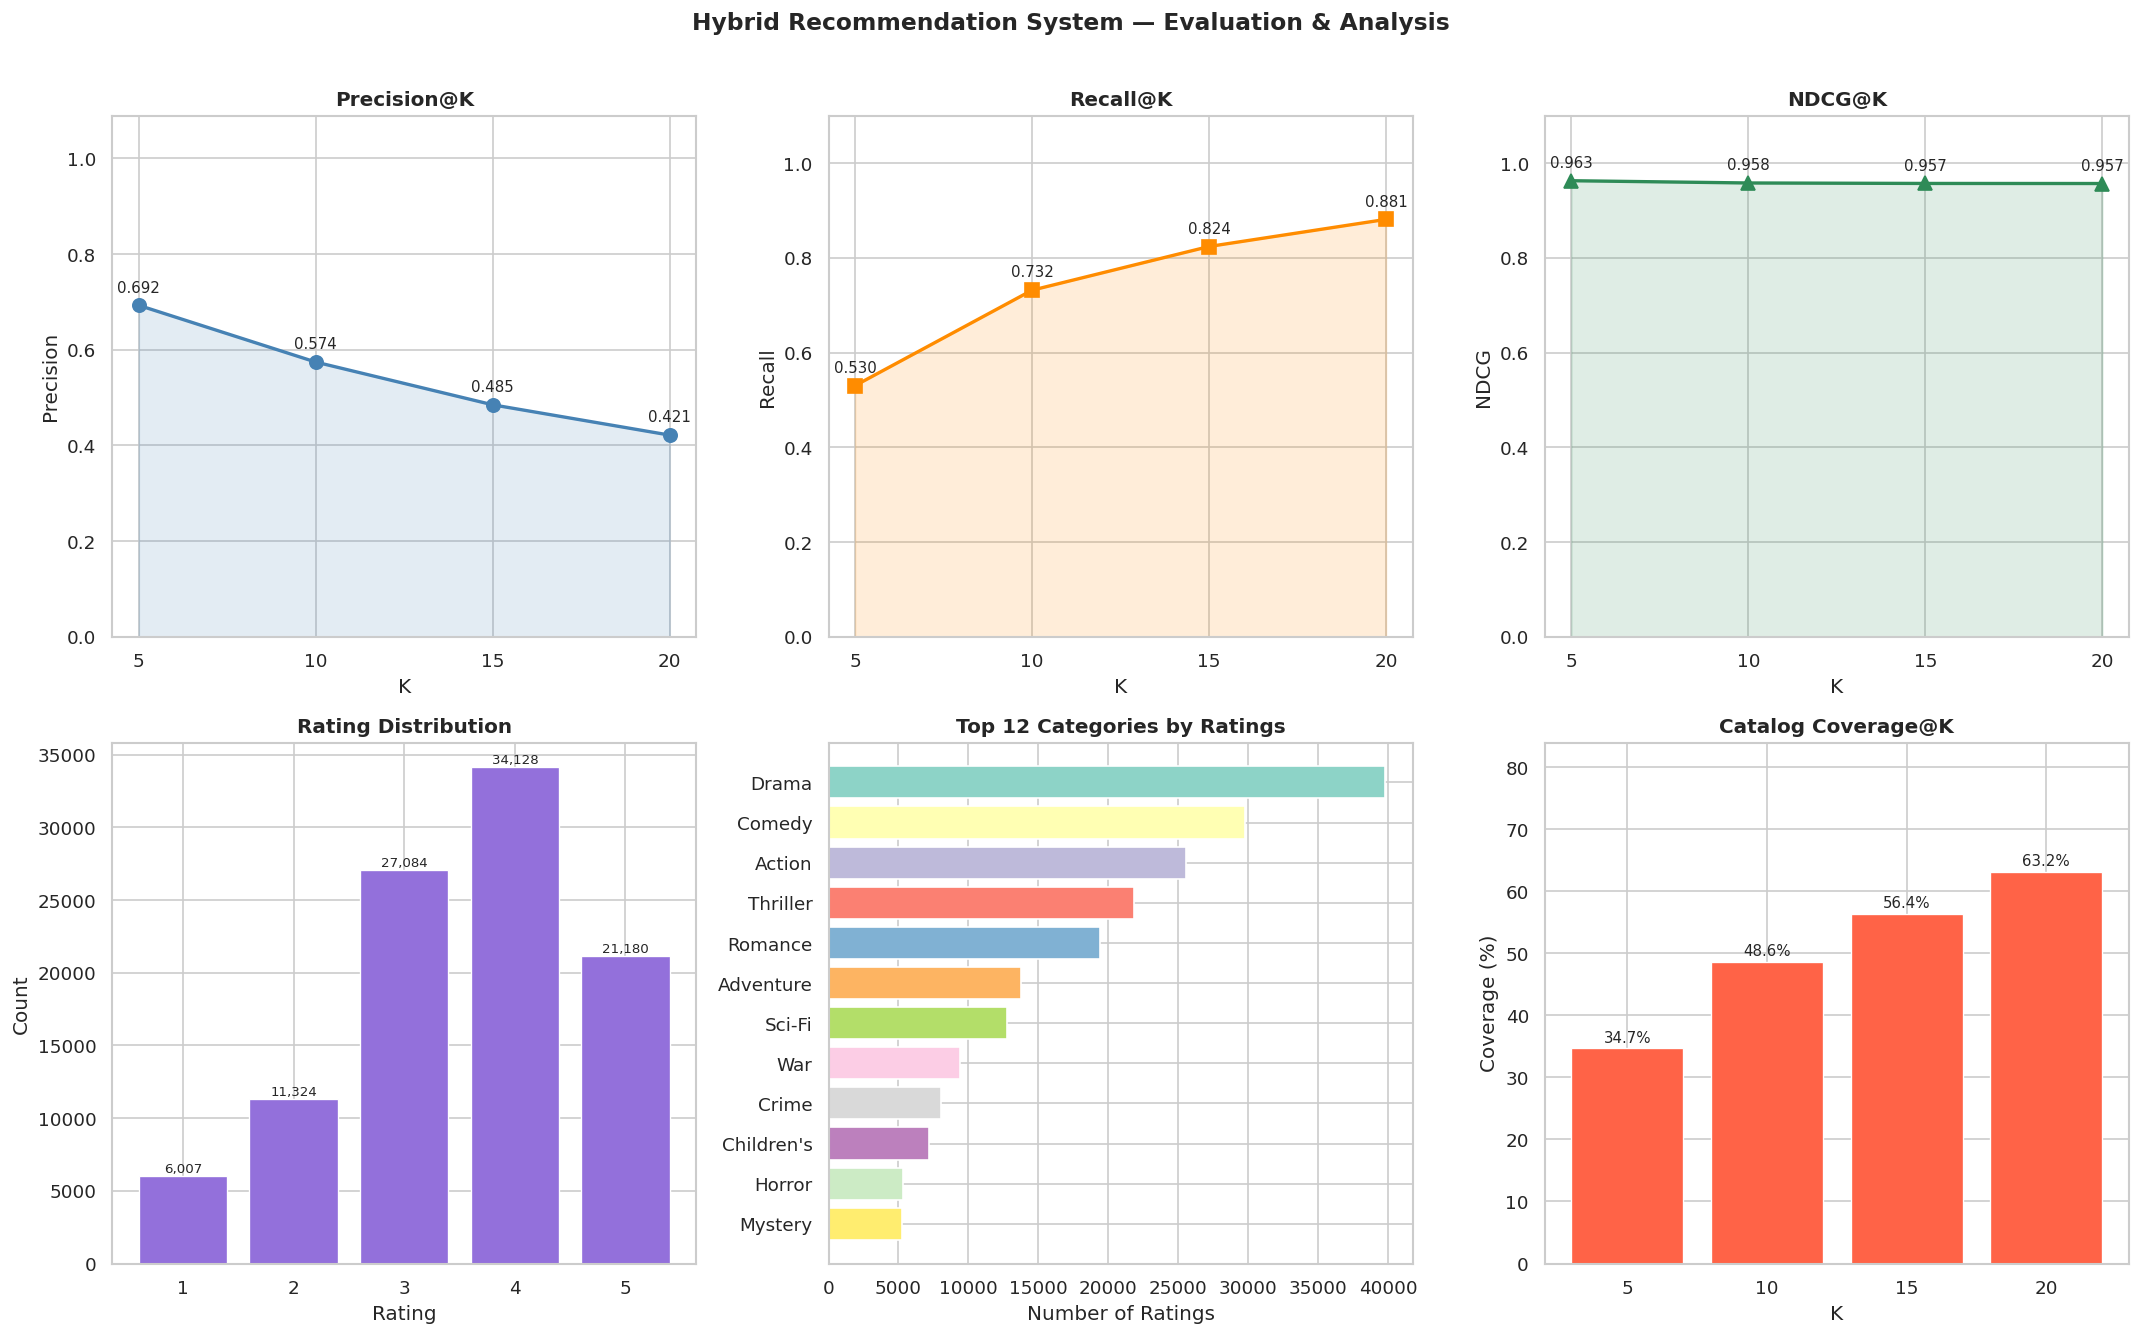

✅ Evaluation plots saved to outputs/evaluation_metrics.png


In [19]:
# ============================================================
# SECTION 13: Recommendation Visualization
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Hybrid Recommendation System — Evaluation & Analysis',
             fontsize=14, fontweight='bold', y=1.01)

k_vals = list(K_VALUES)

# ---- Plot 1: Precision@K ----
ax = axes[0, 0]
prec_vals = [prec_k[k] for k in k_vals]
ax.plot(k_vals, prec_vals, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.fill_between(k_vals, prec_vals, alpha=0.15, color='steelblue')
for k, v in zip(k_vals, prec_vals):
    ax.annotate(f'{v:.3f}', (k, v), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_title('Precision@K', fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('Precision')
ax.set_xticks(k_vals)
ax.set_ylim(0, min(1.1, max(prec_vals) * 1.5 + 0.05))

# ---- Plot 2: Recall@K ----
ax = axes[0, 1]
rec_vals = [rec_k[k] for k in k_vals]
ax.plot(k_vals, rec_vals, 's-', color='darkorange', linewidth=2, markersize=8)
ax.fill_between(k_vals, rec_vals, alpha=0.15, color='darkorange')
for k, v in zip(k_vals, rec_vals):
    ax.annotate(f'{v:.3f}', (k, v), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_title('Recall@K', fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('Recall')
ax.set_xticks(k_vals)
ax.set_ylim(0, min(1.1, max(rec_vals) * 1.5 + 0.05))

# ---- Plot 3: NDCG@K ----
ax = axes[0, 2]
ndcg_vals = [ndcg_k[k] for k in k_vals]
ax.plot(k_vals, ndcg_vals, '^-', color='seagreen', linewidth=2, markersize=8)
ax.fill_between(k_vals, ndcg_vals, alpha=0.15, color='seagreen')
for k, v in zip(k_vals, ndcg_vals):
    ax.annotate(f'{v:.3f}', (k, v), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_title('NDCG@K', fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('NDCG')
ax.set_xticks(k_vals)
ax.set_ylim(0, min(1.1, max(ndcg_vals) * 1.5 + 0.05))

# ---- Plot 4: Rating Distribution ----
ax = axes[1, 0]
rating_counts = filtered_ratings['rating'].value_counts().sort_index()
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values,
               color='mediumpurple', edgecolor='white', linewidth=0.8)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 50,
            f'{int(h):,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Rating Distribution', fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')

# ---- Plot 5: Top Category Distribution ----
ax = axes[1, 1]
cat_series2 = (
    filtered_ratings
    .merge(courses_df[['course_id','course_category']], on='course_id', how='left')
    ['course_category']
    .str.split('|').explode()
)
top_cats = cat_series2.value_counts().head(12)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_cats)))
ax.barh(top_cats.index, top_cats.values, color=colors, edgecolor='white')
ax.set_title('Top 12 Categories by Ratings', fontweight='bold')
ax.set_xlabel('Number of Ratings')
ax.invert_yaxis()

# ---- Plot 6: Coverage Plot ----
ax = axes[1, 2]
cov_vals = [catalog_coverage(cf_predictions, all_course_ids_str, k=k) for k in k_vals]
ax.bar([str(k) for k in k_vals], [v * 100 for v in cov_vals],
        color='tomato', edgecolor='white', linewidth=0.8)
for i, v in enumerate(cov_vals):
    ax.text(i, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Catalog Coverage@K', fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, max(cov_vals) * 100 * 1.25 + 5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'evaluation_metrics.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Evaluation plots saved to outputs/evaluation_metrics.png')

---
## Section 14 — Results Summary

Consolidated results table for the research report.

In [20]:
# ============================================================
# SECTION 14: Results Summary
# ============================================================

print('=' * 60)
print('  HYBRID RECOMMENDATION SYSTEM — RESULTS SUMMARY')
print('=' * 60)
print(f'  Dataset      : MovieLens 100K (adapted to course schema)')
print(f'  Total Users  : {filtered_ratings["user_id"].nunique():,}')
print(f'  Total Courses: {filtered_ratings["course_id"].nunique():,}')
print(f'  Total Ratings: {len(filtered_ratings):,}')
print('  Hybrid Weights: CF α=0.7  |  Content-Based β=0.3')
print('-' * 60)
print('  ERROR METRICS (SVD Collaborative Filtering)')
print(f'    RMSE : {eval_results["RMSE"]:.4f}')
print(f'    MAE  : {eval_results["MAE"]:.4f}')
print('-' * 60)
print('  RANKING METRICS')
print(f'    MAP        : {eval_results["MAP"]:.4f}')
print(f'    Coverage@10: {eval_results["Coverage@10"]:.4f} ({eval_results["Coverage@10"]*100:.1f}%)')
print()
print(f'    {"K":>4}  {"Precision@K":>12}  {"Recall@K":>10}  {"NDCG@K":>10}')
print(f'    {"-"*4}  {"-"*12}  {"-"*10}  {"-"*10}')
for k in K_VALUES:
    print(f'    {k:>4}  {prec_k[k]:>12.4f}  {rec_k[k]:>10.4f}  {ndcg_k[k]:>10.4f}')
print('=' * 60)

# Save as CSV for report
results_rows = []
results_rows.append({'Metric': 'RMSE', 'Value': eval_results['RMSE'], 'K': 'N/A'})
results_rows.append({'Metric': 'MAE',  'Value': eval_results['MAE'],  'K': 'N/A'})
results_rows.append({'Metric': 'MAP',  'Value': eval_results['MAP'],  'K': 'N/A'})
results_rows.append({'Metric': 'Coverage', 'Value': eval_results['Coverage@10'], 'K': 10})
for k in K_VALUES:
    results_rows.append({'Metric': 'Precision', 'Value': prec_k[k], 'K': k})
    results_rows.append({'Metric': 'Recall',    'Value': rec_k[k],  'K': k})
    results_rows.append({'Metric': 'NDCG',      'Value': ndcg_k[k], 'K': k})

results_df = pd.DataFrame(results_rows)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'evaluation_results.csv'), index=False)
print('✅ Results saved to outputs/evaluation_results.csv')

  HYBRID RECOMMENDATION SYSTEM — RESULTS SUMMARY
  Dataset      : MovieLens 100K (adapted to course schema)
  Total Users  : 943
  Total Courses: 1,473
  Total Ratings: 99,723
  Hybrid Weights: CF α=0.7  |  Content-Based β=0.3
------------------------------------------------------------
  ERROR METRICS (SVD Collaborative Filtering)
    RMSE : 0.9346
    MAE  : 0.7353
------------------------------------------------------------
  RANKING METRICS
    MAP        : 0.8062
    Coverage@10: 0.4863 (48.6%)

       K   Precision@K    Recall@K      NDCG@K
    ----  ------------  ----------  ----------
       5        0.6925      0.5301      0.9629
      10        0.5739      0.7316      0.9581
      15        0.4846      0.8239      0.9571
      20        0.4212      0.8812      0.9570
✅ Results saved to outputs/evaluation_results.csv


---
## Section 15 — Example Recommendations

Demonstrate the system generating recommendations for three different user types:
1. **Existing User** — user with rating history (Hybrid)
2. **New User (Cold-Start)** — user with no history
3. **Collaborative Filtering Only** — for comparison

In [21]:
# ============================================================
# SECTION 15: Example Recommendations
# ============================================================

# ---- Helper: pretty-print recommendations ----
def display_recommendations(df: pd.DataFrame, title: str, score_col: str = None):
    print(f'\n{"="*65}')
    print(f'  {title}')
    print(f'{"="*65}')
    if df.empty:
        print('  (No recommendations available)')
        return
    for i, row in df.head(10).iterrows():
        rank = i + 1
        title_str = str(row.get('course_title', 'Unknown'))[:45]
        cat_str   = str(row.get('course_category', 'Unknown'))[:25]
        sc_str    = ''
        if score_col and score_col in row:
            sc_str = f'  [{score_col}: {row[score_col]:.4f}]'
        print(f'  {rank:2}. {title_str:<46} | {cat_str:<26}{sc_str}')
    print()


# ---- Select a sample existing user ----
# Pick a user who has rated at least 10 courses
user_counts_map = filtered_ratings['user_id'].value_counts()
heavy_users = user_counts_map[user_counts_map >= 10].index.tolist()
existing_user_id = heavy_users[2] if len(heavy_users) > 2 else heavy_users[0]

# ---- 1. Existing User — Hybrid Recommendations ----
hybrid_recs = hybrid.recommend(existing_user_id, filtered_ratings, n=10)
display_recommendations(
    hybrid_recs,
    f'Hybrid Recommendations for Existing User ID={existing_user_id}',
    score_col='hybrid_score'
)

# Print user's previous ratings for context
user_history = filtered_ratings[filtered_ratings['user_id'] == existing_user_id].merge(
    courses_df[['course_id','course_title']], on='course_id'
).sort_values('rating', ascending=False)
print(f'  ▶ User {existing_user_id} previously rated {len(user_history)} courses.')
print('  Top-rated by this user:')
for _, row in user_history.head(5).iterrows():
    print(f'    ⭐ {row["rating"]}  {row["course_title"][:50]}')

# ---- 2. New User — Cold-Start Recommendations ----
new_user_recs = recommend_for_new_user(
    filtered_ratings, courses_df, strategy='combined', n=10
)
display_recommendations(
    new_user_recs,
    'Cold-Start: New User (No History) — Popular + Highly Rated',
    score_col='cold_score'
)

# ---- 3. Cold-Start: New Course Similarity ----
new_course_sim = recommend_similar_new_course(
    'Deep Learning for Computer Vision',
    'Artificial Intelligence | Computer Vision',
    cb_model, n=10
)
display_recommendations(
    new_course_sim,
    'Cold-Start: Courses Similar to "Deep Learning for Computer Vision"',
    score_col='similarity_score'
)

# ---- 4. CF-only recommendations for comparison ----
user_rated_set = set(
    filtered_ratings[filtered_ratings['user_id'] == existing_user_id]['course_id'].tolist()
)
cf_recs = cf_model.recommend_cf(
    existing_user_id, courses_df['course_id'].tolist(), user_rated_set, n=10
)
display_recommendations(
    cf_recs,
    f'Collaborative Filtering Only — User ID={existing_user_id}',
    score_col='cf_score'
)

print('✅ Example recommendations complete.')


  Hybrid Recommendations for Existing User ID=13
   1. Fire Down Below (1997)                         | Action|Drama|Thriller       [hybrid_score: 0.6500]
   2. She's the One (1996)                           | Comedy|Romance              [hybrid_score: 0.6345]
   3. Two Much (1996)                                | Comedy|Romance              [hybrid_score: 0.6345]
   4. Nowhere (1997)                                 | Drama                       [hybrid_score: 0.6079]
   5. All Over Me (1997)                             | Drama                       [hybrid_score: 0.6079]
   6. Face/Off (1997)                                | Action|Sci-Fi|Thriller      [hybrid_score: 0.5935]
   7. Men in Black (1997)                            | Action|Adventure|Comedy|S   [hybrid_score: 0.5842]
   8. Solo (1996)                                    | Action|Sci-Fi|Thriller      [hybrid_score: 0.5833]
   9. What Happened Was... (1994)                    | Comedy|Drama|Romance        [hybrid_score: 0.56

---
## Section 16 — Save Outputs

All generated files are saved to the `outputs/` directory and listed here for download.

In [22]:
# ============================================================
# SECTION 16: Save Outputs
# ============================================================

import json

# ---- Save example recommendations to CSV ----
hybrid_recs.to_csv(os.path.join(OUTPUT_DIR, 'hybrid_recommendations.csv'), index=False)
new_user_recs.to_csv(os.path.join(OUTPUT_DIR, 'cold_start_new_user.csv'), index=False)
new_course_sim.to_csv(os.path.join(OUTPUT_DIR, 'cold_start_new_course.csv'), index=False)
cf_recs.to_csv(os.path.join(OUTPUT_DIR, 'cf_recommendations.csv'), index=False)

# ---- Save evaluation summary as JSON ----
eval_summary = {
    'RMSE': round(eval_results['RMSE'], 4),
    'MAE':  round(eval_results['MAE'],  4),
    'MAP':  round(eval_results['MAP'],  4),
    'Coverage@10': round(eval_results['Coverage@10'], 4),
    'Precision@K': {str(k): round(v, 4) for k, v in prec_k.items()},
    'Recall@K':    {str(k): round(v, 4) for k, v in rec_k.items()},
    'NDCG@K':      {str(k): round(v, 4) for k, v in ndcg_k.items()},
    'hybrid_alpha': hybrid.alpha,
    'hybrid_beta':  hybrid.beta,
    'n_users':   int(filtered_ratings['user_id'].nunique()),
    'n_courses': int(filtered_ratings['course_id'].nunique()),
    'n_ratings': int(len(filtered_ratings))
}
with open(os.path.join(OUTPUT_DIR, 'evaluation_summary.json'), 'w') as f:
    json.dump(eval_summary, f, indent=2)

# ---- List all output files ----
print('\n📁 Files saved to outputs/:')
print('-' * 50)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath)
    size_str = f'{size/1024:.1f} KB' if size >= 1024 else f'{size} B'
    print(f'  {fname:<40} {size_str:>10}')
print('-' * 50)

# ---- Colab download helper ----
try:
    from google.colab import files
    print('\n⬇️  Downloading all output files...')
    for fname in os.listdir(OUTPUT_DIR):
        files.download(os.path.join(OUTPUT_DIR, fname))
    print('✅ Download initiated.')
except ImportError:
    print('\nℹ️  Not in Colab — files saved locally in outputs/')

print('\n' + '='*60)
print('  ✅ NOTEBOOK COMPLETE — Hybrid Recommendation System')
print('='*60)


📁 Files saved to outputs/:
--------------------------------------------------
  cf_recommendations.csv                        410 B
  cold_start_new_course.csv                     601 B
  cold_start_new_user.csv                       961 B
  courses.csv                                 69.1 KB
  eda_overview.png                           111.5 KB
  evaluation_metrics.png                     203.7 KB
  evaluation_results.csv                        478 B
  evaluation_summary.json                       458 B
  hybrid_recommendations.csv                    667 B
  ratings.csv                                956.2 KB
--------------------------------------------------

⬇️  Downloading all output files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download initiated.

  ✅ NOTEBOOK COMPLETE — Hybrid Recommendation System


---
## Appendix — Adjusting Hybrid Weights

You can re-run recommendations with different $\alpha$/$\beta$ weights without retraining. For example, to favour content-based filtering more heavily:

In [23]:
# ============================================================
# APPENDIX: Experiment with Different Hybrid Weights
# ============================================================

weight_experiments = [
    (0.9, 0.1, 'CF-heavy'),
    (0.7, 0.3, 'Default (CF=0.7)'),
    (0.5, 0.5, 'Equal weights'),
    (0.3, 0.7, 'CB-heavy'),
]

print(f'Comparing hybrid weights for User ID={existing_user_id}\n')
print(f'{"Config":<22} {"Top Recommendation"}')
print('-' * 70)

for alpha, beta, label in weight_experiments:
    hybrid.set_weights(alpha, beta)
    recs = hybrid.recommend(existing_user_id, filtered_ratings, n=1)
    if not recs.empty:
        top_title = recs.iloc[0]['course_title'][:45]
        top_score = recs.iloc[0]['hybrid_score']
        print(f'{label:<22} {top_title:<46} [{top_score:.4f}]')

# Reset to default
hybrid.set_weights(0.7, 0.3)
print('\n✅ Weights reset to default (α=0.7, β=0.3)')

Comparing hybrid weights for User ID=13

Config                 Top Recommendation
----------------------------------------------------------------------
✅ Weights updated → CF: 0.9, CB: 0.1
CF-heavy               Fire Down Below (1997)                         [0.5500]
✅ Weights updated → CF: 0.7, CB: 0.3
Default (CF=0.7)       Fire Down Below (1997)                         [0.6500]
✅ Weights updated → CF: 0.5, CB: 0.5
Equal weights          Fire Down Below (1997)                         [0.7500]
✅ Weights updated → CF: 0.3, CB: 0.7
CB-heavy               Fire Down Below (1997)                         [0.8500]
✅ Weights updated → CF: 0.7, CB: 0.3

✅ Weights reset to default (α=0.7, β=0.3)
